In [1]:
#import pygeomhpges as hpges
from __future__ import annotations
import sys

import units
import logging
from remage import remage_run
import pygeomtools
import awkward as ak
import numba
import numpy as np
import pint
import pyg4ometry as pg4
import pygeomhpges as hpges
from lgdo import VectorOfVectors
from lgdo.types import LGDO
from numpy.typing import NDArray
from scipy import stats
import subprocess
from numpy import pi
from reboost.units import ureg as u
import surface
import pyg4ometry
from pygeomhpges import make_hpge, draw
import pygeomhpges

import numpy as np
import matplotlib.pyplot as plt

# writing the geometry

In [2]:
reg = pg4.geant4.Registry()
world_s = pg4.geant4.solid.Box("World_s", 400, 400, 400, registry=reg, lunit="mm")
world_l = pg4.geant4.LogicalVolume(world_s, "G4_Galactic", "World_l", registry=reg)
reg.setWorld(world_l)

In [3]:
'''
#Now we create our own argon! We don't need your stupid NIST materials! We prefer doping anyways.

# If we want we can specify the exact isotope composition of our material
argon_36 = pg4.geant4.Isotope(name="Argon36", Z=18, N=36, a=35.97, registry=reg)
argon_38 = pg4.geant4.Isotope(name="Argon38", Z=18, N=38, a=37.97, registry=reg)
argon_40 = pg4.geant4.Isotope(name="Argon40", Z=18, N=40, a=39.97, registry=reg)
argon_element = pg4.geant4.ElementIsotopeMixture(name="Argon", symbol="Ar", n_comp=3, registry=reg)  # sto dicendoc he l'elemento argon è composto da 3 elementi
argon_element.add_isotope(argon_36, 0.00337)
argon_element.add_isotope(argon_38, 0.00063)
argon_element.add_isotope(argon_40, 0.996)

xenon_element = pg4.geant4.ElementSimple(name="Xenon", symbol="Xe", Z=54, A=131.249, registry=reg)
# We need to make a material out of these elements to apply it to a volume.
doped_liquidargon = pg4.geant4.Material(
            name="LiquidArgon",
            density=1.390,  # g/cm3
            number_of_components=2,
            state="liquid",
            temperature=88.8,  # K
            pressure=1.0 * 1e5,  # pascal
            registry=reg,
        )
# We have the option to add by massfraction or by number of atoms (replace "massfraction" with "natoms").
doped_liquidargon.add_element_massfraction("Argon", 0.999)
doped_liquidargon.add_element_massfraction("Xenon", 0.001) # I have no idea how much you usually dope.
'''

'\n#Now we create our own argon! We don\'t need your stupid NIST materials! We prefer doping anyways.\n\n# If we want we can specify the exact isotope composition of our material\nargon_36 = pg4.geant4.Isotope(name="Argon36", Z=18, N=36, a=35.97, registry=reg)\nargon_38 = pg4.geant4.Isotope(name="Argon38", Z=18, N=38, a=37.97, registry=reg)\nargon_40 = pg4.geant4.Isotope(name="Argon40", Z=18, N=40, a=39.97, registry=reg)\nargon_element = pg4.geant4.ElementIsotopeMixture(name="Argon", symbol="Ar", n_comp=3, registry=reg)  # sto dicendoc he l\'elemento argon è composto da 3 elementi\nargon_element.add_isotope(argon_36, 0.00337)\nargon_element.add_isotope(argon_38, 0.00063)\nargon_element.add_isotope(argon_40, 0.996)\n\nxenon_element = pg4.geant4.ElementSimple(name="Xenon", symbol="Xe", Z=54, A=131.249, registry=reg)\n# We need to make a material out of these elements to apply it to a volume.\ndoped_liquidargon = pg4.geant4.Material(\n            name="LiquidArgon",\n            density=1

In [4]:
# let's start with a liquid argon balloon
# For a solid orb we specify the name and radius (and the registry of course).
'''
lar_s = pg4.geant4.solid.Orb("LAr_s", 150, registry=reg, lunit="mm")
lar_l = pg4.geant4.LogicalVolume(lar_s, "G4_lAr", "LAr_l", registry=reg)
lar_pv =pg4.geant4.PhysicalVolume([0, 0, 0], [0, 0, 0], lar_l, "LAr", world_l, registry=reg)
'''

'\nlar_s = pg4.geant4.solid.Orb("LAr_s", 150, registry=reg, lunit="mm")\nlar_l = pg4.geant4.LogicalVolume(lar_s, "G4_lAr", "LAr_l", registry=reg)\nlar_pv =pg4.geant4.PhysicalVolume([0, 0, 0], [0, 0, 0], lar_l, "LAr", world_l, registry=reg)\n'

In [5]:
vac_s = pg4.geant4.solid.Tubs(
    "Vacuum_s",
    0,          # raggio interno
    150,        # raggio esterno
    300,        # half-height -> altezza totale 300 mm
    0,
    2*pi,
    registry=reg,
    lunit="mm"
)

vac_l = pg4.geant4.LogicalVolume(
    vac_s,
    "G4_Galactic",   # vuoto di Geant4
    "Vacuum_l",
    registry=reg
)

vac_pv = pg4.geant4.PhysicalVolume(
    [0, 0, 0],
    [0, 0, 0],
    vac_l,
    "Vacuum",
    world_l,
    registry=reg
)

In [6]:
source_s = pg4.geant4.solid.Tubs(
    "Source_s",
    0,
    1,
    1,
    0,
    2*pi,
    registry=reg
)

source_l = pg4.geant4.LogicalVolume(
    source_s,
    "G4_BRAIN_ICRP",
    "Source_L",
    registry=reg
)

source_pv = pg4.geant4.PhysicalVolume(
    [0, 0, 0],
    [0, 0, 1, "mm"],
    source_l,
    "Source",
    vac_l,
    registry=reg
)

In [7]:
# We have two different detectors, Corgi and Bob. Although Bob doesnt seem very happy for some reason...
bege_meta = {
    "name": "bege_hpge",
    "type": "bege",
    "production": {
        "enrichment": {"val": 0.855, "unc": 0.015},
    },
    "geometry": {
        "height_in_mm": 30,
        "radius_in_mm": 37,
        "borehole": {"radius_in_mm": 6.75, "depth_in_mm": 25},
        "groove": {"depth_in_mm": 2.0, "radius_in_mm": {"outer": 10.5, "inner": 7.5}},
        "pp_contact": {"radius_in_mm": 7.5, "depth_in_mm": 0},
        "taper": {
            "top": {"angle_in_deg": 0.0, "height_in_mm": 0.0},
            "bottom": {"angle_in_deg": 0.0, "height_in_mm": 0.0},
            "borehole": {"angle_in_deg": 0, "height_in_mm": 0},
        },
    },
}


In [8]:
bege_meta = {
    "name": "bege_hpge",
    "type": "bege",
    "production": {
        "enrichment": {"val": 0.855, "unc": 0.015},
    },
    "geometry": {
        "height_in_mm": 42.6,
        "radius_in_mm": 40,

        "borehole": {
            "radius_in_mm": 1.6,
            "depth_in_mm": 1.2,
        },

        "groove": {
            "depth_in_mm": 1.5,
            "radius_in_mm": {
                "outer": 8,
                "inner": 5,
            },
        },

        "pp_contact": {
            "radius_in_mm": 1.6,
            "depth_in_mm": 1.2,
        },

        "taper": {
            "top": {
                "angle_in_deg": 0.0,
                "height_in_mm": 0.0,
            },
            "bottom": {
                "angle_in_deg": 0.0,
                "height_in_mm": 0.0,
            },
            "borehole": {
                "angle_in_deg": 0,
                "height_in_mm": 0,
            },
        },

        "corner_radius_in_mm": 2,
    },
}

In [9]:
bob_l = hpges.make_hpge(bege_meta, name="Bob_L", registry=reg)
# We shift them a little bit so they do not overlap! That would again be a malformed geometry.
bob_pv = pg4.geant4.PhysicalVolume(
    [0, 0, 0], [0, 0, -4.31, "cm"], bob_l, "Bob", vac_l, registry=reg
)

In [10]:
bob_pv.set_pygeom_active_detector(
    pygeomtools.RemageDetectorInfo("germanium", 1, bege_meta)
)

In [11]:
# foglio di polietilene
# foglio di polietilene
poly = pg4.geant4.MaterialPredefined("G4_POLYETHYLENE")

poly_s = pg4.geant4.solid.Box(
    "Poly_s",
    80,     # half-length X -> 74 mm totale
    80,     # half-length Y -> 74 mm totale
    1,    # half-length Z -> 1 mm totale
    registry=reg
)
poly_l = pg4.geant4.LogicalVolume(
    poly_s,
    poly,
    "Polyethylene_L",
    registry=reg
)

poly_pv = pg4.geant4.PhysicalVolume(
    [0, 0, 0],
    [0, 0, 0, "mm"],
    poly_l,
    "Polyethylene",
    vac_l,
    registry=reg
)

In [12]:
# Write the geometry file if you do not have x-support for visualization
vac_l.pygeom_color_rgba = (0, 0, 1, 0.1)
bob_l.pygeom_color_rgba    = (0.95, 0.55, 0.10, 0.75)   # arancione caldo
source_l.pygeom_color_rgba = (0.10, 0.85, 0.25, 1.00)   # verde smeraldo
poly_l.pygeom_color_rgba = (0.9, 0.9, 0.9, 0.4)

In [13]:
# FONDAMENTTALE : DEVI CREARE IL REGISTRO
reg.detector_aux = None
pygeomtools.write_pygeom(reg, "geometry.gdml")

In [14]:
macro_content = [
"/RMG/Manager/Logging/LogLevel summary",
"/RMG/Processes/HadronicPhysics Shielding",
"/RMG/Geometry/RegisterDetectorsFromGDML Germanium",
"/RMG/Output/NtupleUseVolumeName true",
"/run/initialize",
"/RMG/Generator/Confine Volume",
"/RMG/Generator/Confinement/Physical/AddVolume Source",
"/RMG/Processes/Stepping/ResetInitialDecayTime true",
"/RMG/Generator/Select GPS",
"/gps/particle ion",
"/gps/ion 56 133",
"/gps/energy 0 keV",
"/process/had/rdm/nucleusLimits 133 133 56 56",
"/run/beamOn 450000",  
]

In [15]:
try:
    # Run remage
    remage_run(macros=macro_content,
              gdml_files="geometry.gdml",
              output="out.lh5",
              overwrite_output=True
              )
except Exception as e:
    # Catch any error that remage_run might raise
    print(f"❌ Simulation failed: {e}")

  _ __ ___ _ __ ___   __ _  __ _  ___ 
 | '__/ _ \ '_ ` _ \ / _` |/ _` |/ _ \
 | | |  __/ | | | | | (_| | (_| |  __/ v0.24.0
 |_|  \___|_| |_| |_|\__,_|\__, |\___| using geant4-11-04 [MT]
                           |___/      

G4GDML: Reading 'geometry.gdml'...
G4GDML: Reading definitions...
G4GDML: Reading materials...
G4GDML: Reading solids...
G4GDML: Reading structure...
G4GDML: Reading userinfo...
G4GDML: Reading setup...
G4GDML: Reading 'geometry.gdml' done!
Stripping off GDML names of materials, solids and volumes ...


[Summary -> CLHEP::HepRandom seed changed to: 1227616018 (from system entropy)
[Summary -> Checking for overlaps in GDML geometry...
[Summary -> Opening output file: .rmg-tmp-39212.out.hdf5 (for out.lh5)
[Summary -> Starting run nr. 0. Current local time is 17-08-2026 00:40:00 PDT
[Summary -> Number of events to be processed: 450000
[Summary -> Processing event nr. 45000 (10%), at 0 days, 0 hours, 0 minutes and 12 seconds
[Summary -> Processing event nr. 90000 (20%), at 0 days, 0 hours, 0 minutes and 24 seconds
[Summary -> Processing event nr. 135000 (30%), at 0 days, 0 hours, 0 minutes and 37 seconds
[Summary -> Processing event nr. 180000 (40%), at 0 days, 0 hours, 0 minutes and 49 seconds
[Summary -> Processing event nr. 225000 (50%), at 0 days, 0 hours, 1 minutes and 1 seconds
[Summary -> Processing event nr. 270000 (60%), at 0 days, 0 hours, 1 minutes and 13 seconds
[Summary -> Processing event nr. 315000 (70%), at 0 days, 0 hours, 1 minutes and 25 seconds
[Summary -> Processing e

# post processing

In [204]:
import lh5
import awkward as ak
import hist
import matplotlib.pyplot as plt

In [205]:
# This just runs the command line command lh5ls to investigate the data structure
!lh5ls out.lh5

/
├── detector_origins · struct{Bob} 
│   └── Bob · struct{xloc,yloc,zloc} 
│       ├── xloc · real 
│       ├── yloc · real 
│       └── zloc · real 
├── number_of_simulated_events · real 
├── stp · struct{Bob} 
│   ├── Bob · table{dist_to_surf,edep,evtid,particle,t0,time,xloc,yloc,zloc} 
│   │   ├── dist_to_surf · array<1>{array<1>{real}} 
│   │   │   ├── cumulative_length · array<1>{real} 
│   │   │   └── flattened_data · array<1>{real} 
│   │   ├── edep · array<1>{array<1>{real}} 
│   │   │   ├── cumulative_length · array<1>{real} 
│   │   │   └── flattened_data · array<1>{real} 
│   │   ├── evtid · array<1>{real} 
│   │   ├── particle · array<1>{array<1>{real}} 
│   │   │   ├── cumulative_length · array<1>{real} 
│   │   │   └── flattened_data · array<1>{real} 
│   │   ├── t0 · array<1>{real} 
│   │   ├── time · array<1>{array<1>{real}} 
│   │   │   ├── cumulative_length · array<1>{real} 
│   │   │   └── flattened_data · array<1>{real} 
│   │   ├── xloc · array<1>{array<1>{real}} 

In [206]:
data = lh5.read_as("/stp/Bob", "out.lh5", "ak")

In [207]:
print(f"Type of data: {ak.type(data)}")
print(f"Fields of data: {data.fields}")

Type of data: 338534 * {dist_to_surf: var * float64, edep: var * float64, evtid: int64, particle: var * int32, t0: float64, time: var * float64, xloc: var * float64, yloc: var * float64, zloc: var * float64}
Fields of data: ['dist_to_surf', 'edep', 'evtid', 'particle', 't0', 'time', 'xloc', 'yloc', 'zloc']


In [208]:
print(f"Energy field shape: {ak.type(data.edep)}")
print(f"Energy field: {data.edep}")
print(f"Event id field: {data.evtid}")

Energy field shape: 338534 * var * float64
Energy field: [[0.0906, 19.5, 0.0377, 1.15, 0.0178, ..., 8.59, 1.18, 0.0178, 0.0171], ...]
Event id field: [1, 2, 3, 4, 5, 6, 7, ..., 449994, 449995, 449996, 449997, 449998, 449999]


/tmp/ipykernel_243297/1625544252.py:77: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


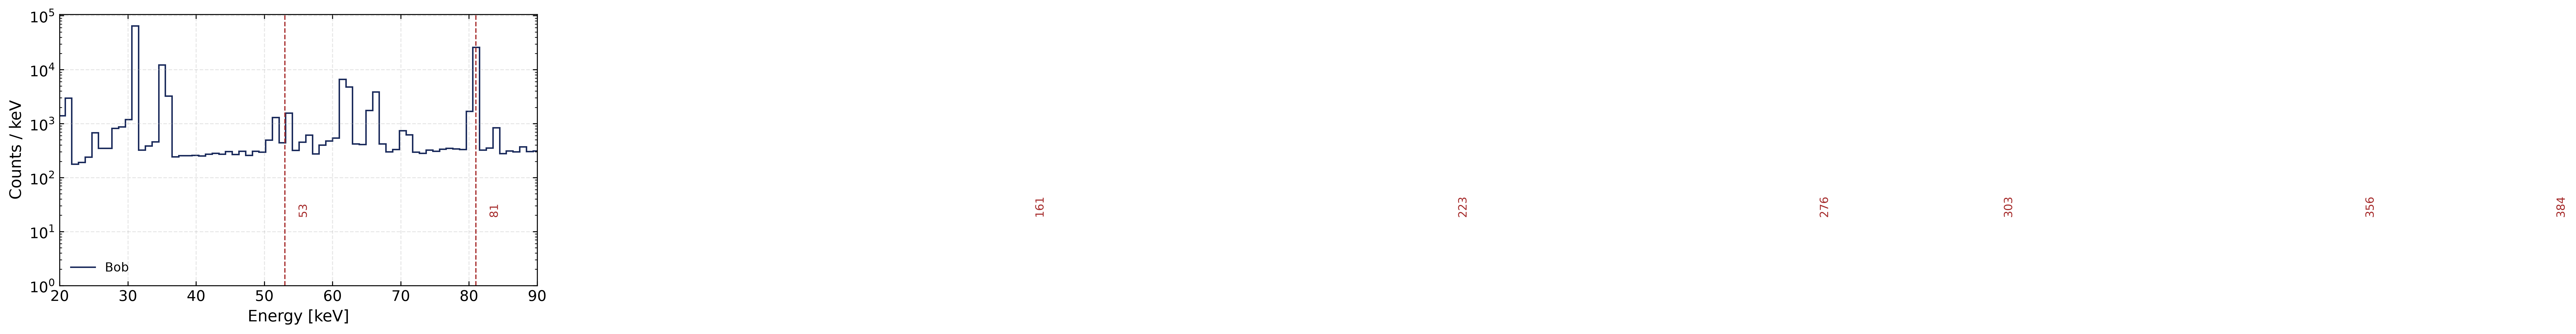

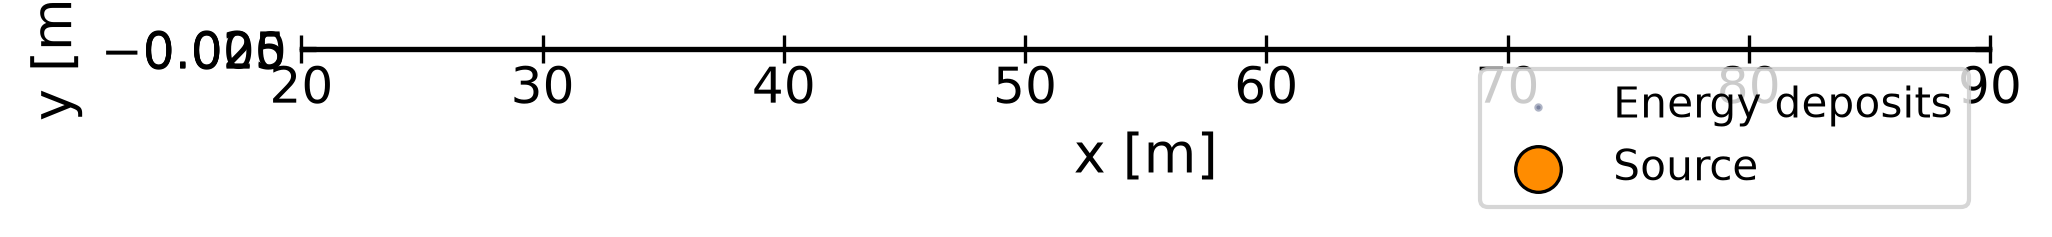

In [209]:
plt.style.use("default")

plt.rcParams.update({
    "figure.figsize": (7, 4),
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

# ------------------
# Energy spectrum
# ------------------

fig, ax = plt.subplots(dpi = 300)

def plot_edep(detid):
    data = lh5.read_as(f"stp/{detid}", "out.lh5", "ak")

    (
        hist.new
        .Reg(500, 10, 500, name="Energy [keV]")
        .Double()
        .fill(ak.sum(data.edep, axis=-1))
        .plot(
            ax=ax,
            yerr=False,
            histtype="step",
            color="#1A2A5B",
            #edgecolor="#1A2A5B",
            linewidth=1.2,
            label=detid,
        )
    )

plot_edep("Bob")

gamma_lines = {
    53: "53",
    81: "81",
    161: "161",
    223: "223",
    276: "276",
    303: "303",
    356: "356",
    384: "384",
}

for E, label in gamma_lines.items():
    ax.axvline(E, color="brown", ls="--", lw=1)
    ax.text(
        E + 2,
        20,
        label,
        rotation=90,
        color="brown",
        fontsize=9,
    )

ax.set_yscale("log")
ax.set_xlim(20, 90)
ax.set_ylim(1, None)

ax.set_xlabel("Energy [keV]")
ax.set_ylabel("Counts / keV")
#ax.set_title(r"$^{133}$Ba simulated energy spectrum")

ax.legend(frameon=False)

plt.tight_layout()


# ------------------
# Hit positions
# ------------------

fig, ax = plt.subplots(figsize=(7, 4), dpi=300)

def plot_hits(detid):
    data = lh5.read_as(f"stp/{detid}", "out.lh5", "ak")[:10_000]

    ax.scatter(
        ak.flatten(data.xloc),
        ak.flatten(data.yloc),
        s=1,
        alpha=0.35,
        color="#1A2A5B",
        rasterized=True,
        label="Energy deposits",
    )

plot_hits("Bob")

ax.scatter(
    0,
    0,
    s=120,
    color="darkorange",
    edgecolor="black",
    linewidth=0.8,
    label="Source",
)

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
#ax.set_title(r"$^{133}$Ba interaction positions")
ax.set_aspect("equal")
ax.legend()
plt.xlim(20,90)
plt.tight_layout()
plt.show()

# Reboost

In [210]:
import reboost
import numpy as np
from reboost import hpge
from reboost.hpge import surface, psd
from reboost.shape import group
from reboost.math import functions
from reboost.math.stats import gaussian_sample


In [211]:
data.edep

<Array [[0.0906, 19.5, ..., 0.0178, 0.0171], ...] type='338534 * var * float64'>

In [212]:
# -----------------------------
# Spectrum plot
# -----------------------------
def plot_edep_reboost_deadlayer(detid, dlf, color=None, ax=None):
    if ax is None:
        ax = plt.gca()

    data = lh5.read_as(f"stp/{detid}", "out.lh5", "ak", with_units=True)

    fccd_in_mm = 0.95

    charge_collection_eff = reboost.math.functions.piecewise_linear_activeness(
        data.dist_to_surf,
        fccd_in_mm=fccd_in_mm,
        dlf=dlf,
    )

    energy = ak.sum(data.edep * charge_collection_eff, axis=-1)
    energy_smeared = reboost.math.stats.gaussian_sample(
        energy,
        sigma=0.6,)
    

    (
        hist.new
        .Reg(800, 10, 500, name="Energy [keV]")
        .Double()
        .fill(energy_smeared)
        .plot(
            ax=ax,
            yerr=False,
            histtype="fill",
            alpha=0.7,
            color=color,
            edgecolor="black",
            linewidth=0.4,
            label=f"Dead layer = {fccd_in_mm * dlf:.2f} mm",
        )
    )
    return energy_smeared


# -----------------------------
# CCE function
# -----------------------------
def plot_cce(dlf, color, ax=None):
    if ax is None:
        ax = plt.gca()

    x = np.linspace(0, 1.2, 500)
    fccd_in_mm= 0.95
    y = reboost.math.functions.piecewise_linear_activeness(
        x,
        fccd_in_mm=fccd_in_mm,
        dlf=dlf,
    )

    ax.plot(
        x,
        y,
        color=color,
        lw=2,
        label=f"dlf = {fccd_in_mm*dlf:.1f} mm",
    )



In [213]:
E_exp = np.array([
19.07963354, 19.44834390, 19.95687104, 20.46708950, 20.90345314,
21.63241720, 22.06765328, 22.57167019, 23.08245243, 23.52163495,
23.95743481, 24.46821705, 24.97730796, 25.63636364, 26.00056378,
    
26.58012685, 27.01818182, 27.60169133, 28.11247357, 28.40394644,
28.98632840, 29.63918252, 30.00281889, 30.58632840, 31.16476392,
31.53234672, 31.96871036, 32.54883721, 32.98801973, 33.56871036,
    
34.00225511, 34.65905567, 35.24031008, 35.68287526, 36.19252995,
36.63002114, 37.14193094, 37.57660324, 38.08569415, 38.74080338,
39.17942213, 39.68794926, 40.19196617, 40.92036646, 41.64933051,
    
42.23002114, 42.58914729, 43.17773080, 43.46863989, 44.04933051,
44.49020437, 45.07202255, 45.50613108, 45.94305849, 46.45214940,
47.10669486, 47.54531360, 48.12769556, 48.41634954, 48.99929528,
    
49.65271318, 50.08907681, 50.74418605, 51.32544045, 51.68625793,
    
52.18858351, 52.90345314, 53.64256519, 54.16124031, 54.59873150,
55.11176885, 55.90894996, 56.56575053, 57.14813249, 57.72825934,
58.01578576, 58.67258633, 59.18393235, 59.69245948, 60.27484144,
60.63622269, 60.99760395, 61.65440451, 62.08907681, 62.59929528,
63.10331219, 63.54249471, 63.90613108, 64.55560254, 64.99478506,
65.57773080, 66.15673009, 66.88400282, 67.39252995, 68.04763918,
68.70049331, 69.06243834, 69.93516561, 70.51642001, 71.24312896,
71.96927414, 72.47554616, 73.13065539, 73.78632840, 74.14545455,
74.58012685, 75.30627202, 75.67047216, 76.17899930, 76.61423538,
77.19267089, 77.62734320, 78.05976039, 78.55081043, 79.03171247,
79.43537703, 80.04312896, 80.45243129, 80.74446794, 81.03763214,
81.36744186, 82.08569415, 82.49556025, 83.09823820, 83.68513037,
84.05045807, 84.77942213, 85.21296688, 85.79985906, 86.16067653,
86.74418605, 87.32656801, 87.91289641, 88.56518675, 89.22029598,
89.65384073, 90.38449612, 91.33276956
])
N_exp= np.array([
2822.2046, 2552.59797, 2581.234963, 2524.278684, 2524.278684,
2441.192018, 2496.273581, 2759.931202, 2669.088031, 2524.278684,
2552.59797, 2468.579175, 2468.579175, 2257.803306, 2232.75456,
    
2334.648284, 2257.803306, 2183.48768, 2111.618155, 2088.191231,
2065.024213, 2135.3079, 2135.3079, 2065.024213, 2207.983713,
2042.114216, 2042.114216, 2111.618155, 1997.053914, 2042.114216,
    
2159.263415, 2065.024213, 2088.191231, 1847.030014, 1826.53851,
1786.234997, 1689.324173, 1746.820802, 1746.820802, 1727.441049,
1652.048364, 1670.582305, 1847.030014, 1806.274345, 1746.820802,
    
1786.234997, 1952.987891, 1708.276301, 1708.276301, 1746.820802,
    
1597.671171, 1597.671171, 1670.582305, 1652.048364, 1652.048364,
1652.048364, 1579.946129, 1562.417734, 1633.720045, 1597.671171,
1633.720045, 1633.720045, 1615.595066, 1633.720045, 1727.441049,
1974.898, 2524.278684, 1997.053914, 1652.048364, 1615.595066,
1494.22735, 1579.946129, 1510.990734, 1494.22735, 1545.083804,
1652.048364, 1579.946129, 1510.990734, 1527.942182, 1510.990734,
1579.946129, 1652.048364, 1579.946129, 1633.720045, 1597.671171,
1766.417972, 1670.582305, 1670.582305, 1847.030014, 1746.820802,
1708.276301, 1806.274345, 1806.274345, 1826.53851, 1806.274345,
1867.751407, 1931.320858, 1931.320858, 1952.987891, 1974.898,
2019.45839, 2135.3079, 2111.618155, 2065.024213, 2257.803306,
2334.648284, 2387.325859, 2360.840151, 2387.325859, 2441.192018,
2610.193228, 2699.031898, 2918.259138, 4170.303662, 7284.901041,
13913.63449, 35122.50737, 60000, 58676.06909, 56115.20233,
25987.66649, 7366.628624, 2950.998397, 1952.987891, 1766.417972,
1708.276301, 1652.048364, 1746.820802, 1579.946129, 1670.582305,
1615.595066, 1597.671171, 1461.256454, 1527.942182, 1510.990734,
1597.671171, 1494.22735, 1413.159179
])

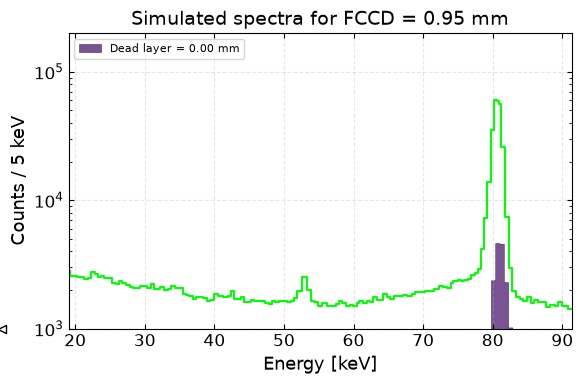

In [214]:
# -------------------------------
# Plot spectra
# -------------------------------
fig, ax = plt.subplots(figsize=(6, 4))#, dpi = 300)

dlfs = np.arange(0.2, 1.2, 0.2)
dlfs = [0]
colors = plt.colormaps["inferno"](np.linspace(0.2, 0.8, len(dlfs)))

for dlf, color in zip(dlfs, colors):
    energy_smeared = plot_edep_reboost_deadlayer(
        "Bob",
        dlf=dlf,
        color=color,
        ax=ax)
    

#plot_edep("Bob")
ax.set_yscale("log")
ax.set_xlim(min(E_exp), max(E_exp))
ax.set_ylim(1e3, 2e5)
plt.step(E_exp, N_exp, where="mid", color = 'lime')
ax.set_xlabel("Energy [keV]")
ax.set_ylabel("Counts / 5 keV")
ax.set_title("Simulated spectra for FCCD = 0.95 mm")
ax.grid(alpha=0.3)
ax.legend( fontsize=8, loc = "upper left")
plt.tight_layout()
plt.show()



In [215]:
import awkward as ak
import json
# converte in liste Python
data_list = ak.to_list(energy_smeared)

# salva in JSON
with open("energy_smeared.json", "w") as f:
    json.dump(data_list, f)

In [216]:
data = lh5.read_as(f"stp/Bob", "out.lh5", "ak", with_units=True)
energy = ak.sum(data.edep , axis=-1)

In [217]:
import awkward as ak
import json
# converte in liste Python
data_list = ak.to_list(energy)

# salva in JSON
with open("energy.json", "w") as f:
    json.dump(data_list, f)

In [218]:
data.edep

<Array [[0.0906, 19.5, ..., 0.0171], ...] type='338534 * [var * float64, pa...'>

In [219]:
import awkward as ak

ak.to_parquet(data.edep, "edep.parquet")
edep = ak.from_parquet("edep.parquet")

In [220]:
energy_smeared = reboost.math.stats.gaussian_sample(energy, sigma=0.6,)

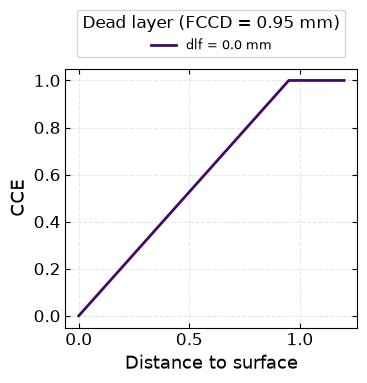

In [221]:

# -------------------------------
# Plot CCE curves (NEW FIGURE)
# -------------------------------
fig2, ax2 = plt.subplots(figsize=(4,4))

for dlf, color in zip(dlfs, colors):
    plot_cce(
        dlf=dlf,
        color=color,
        ax=ax2,
    )

ax2.set_xlabel("Distance to surface")
ax2.set_ylabel("CCE")

ax2.grid(alpha=0.3)
# legenda fuori a destra
ax2.legend(
    title="Dead layer (FCCD = 0.95 mm)",
    fontsize=9.,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
)


plt.tight_layout()
plt.show()

## Experimental data

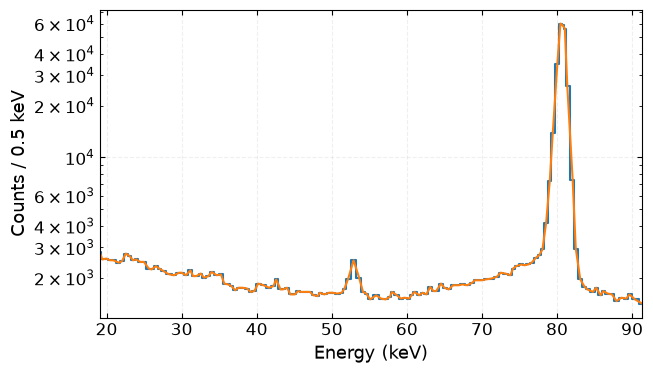

In [222]:
emin , emax = 10, 110
bin_width = 1
bins = np.arange(emin, emax  , bin_width)
plt.step(E_exp, N_exp, where="mid")
plt.plot(E_exp, N_exp)
plt.xlabel("Energy (keV)")
plt.ylabel("Counts / 0.5 keV")
plt.grid()
plt.xlim(min(E_exp), max(E_exp))
plt.grid(alpha = 0.2)
plt.yscale('log')

# defining CCE

In [223]:
import simulate_CCE
import argparse

In [224]:
 data = lh5.read_as(f"stp/Bob","out.lh5", "ak", with_units=True)


In [225]:
import importlib
importlib.reload(simulate_CCE)

--------------------------------
CCE simulation
--------------------------------
seed = 1
--------------------------------


<module 'simulate_CCE' from '/global/u2/r/ritaferi/CTM/simulation/simulate_CCE.py'>

In [226]:
my_args = argparse.Namespace(

    seed=1,

    N_charges=15,

    N_repeat=125,

    alpha=2.5e-10,

    # IN CM 
    FCCD = 0.09, 

    T_ann=623,

    t_ann=18*60,

    output="library"
)


params = simulate_CCE.update_parameters(my_args)

In [227]:
cells, saturation_depth, px, py, pz = simulate_CCE.generate_lithium(params)

print("Numero Li:", len(px))
print("Profondità saturazione:", saturation_depth*10, "mm")



Generating Li distribution...
alpha 2.50e-10
Saturation depth = 0.66 mm


Li slices: 100%|██████████| 66/66 [00:03<00:00, 18.46it/s]

Total Li particles = 16620
Numero Li: 16620
Profondità saturazione: 0.66 mm


In [228]:
x, CCE_matrix, CCE_mean, CCE_std = simulate_CCE.simulate_CCE(
    cells,
    saturation_depth,
    px,
    py,
    pz,
    my_args
)


Starting CCE simulation...



CCE depth:   0%|          | 0/21 [00:00<?, ?it/s]

Charge initial position: 0.0


CCE depth:  19%|█▉        | 4/21 [00:00<00:01, 11.15it/s]

Charge initial position: 0.005
Charge initial position: 0.01
Charge initial position: 0.015
Charge initial position: 0.02
Charge initial position: 0.025


...

Charge initial position: 0.08


CCE depth:  81%|████████  | 17/21 [00:37<00:13,  3.38s/it]

Charge initial position: 0.085


CCE depth: 100%|██████████| 21/21 [00:38<00:00,  1.85s/it]

Charge initial position: 0.09
Charge initial position: 0.095
Charge initial position: 0.1


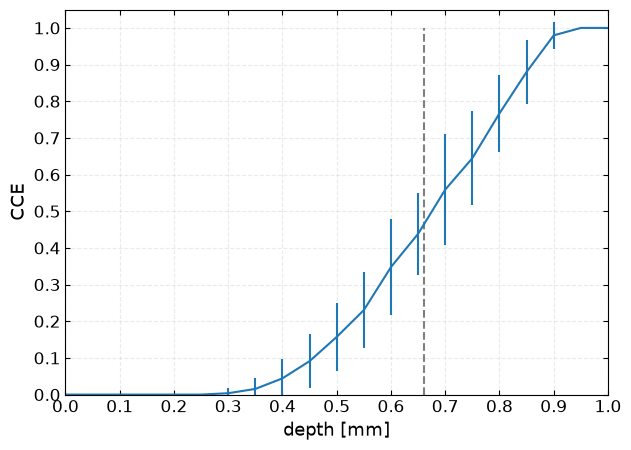

In [229]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.errorbar(
    x*10,
    CCE_mean,
    yerr=CCE_std
)

plt.xlabel("depth [mm]")
plt.ylabel("CCE")

# limiti
plt.xlim(0, 1.0)
plt.ylim(0, 1.05)

# ticks ogni 0.1
plt.xticks(
    np.arange(0, 1.01, 0.1)
)

plt.yticks(
    np.arange(0, 1.01, 0.1)
)


plt.vlines(
    0.66,
    0,
    1,
    color='grey',
    ls='--'
)

plt.grid(
    alpha=0.25
)

plt.show()

In [230]:
from scipy.interpolate import interp1d

# punti della tua curva
depth = np.array(x) * 10   # mm
cce = CCE_mean

# funzione interpolante
cce_interp = interp1d(
    depth,
    cce,
    kind='linear',          # oppure 'cubic'
    bounds_error=False,
    fill_value=(cce[0], 1.0)   # fuori dall'intervallo
)

cce_interp_cubi = interp1d(
    depth,
    cce,
    kind='cubic',          # oppure 'cubic'
    bounds_error=False,
    fill_value=(cce[0], 1.0)   # fuori dall'intervallo
)

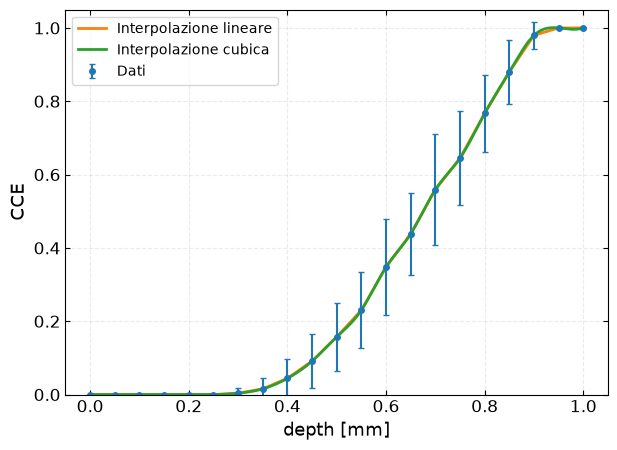

In [231]:
import numpy as np
import matplotlib.pyplot as plt

depth = np.array(x) * 10   # da cm a mm
cce = CCE_mean

# Griglia fitta
depth_fine = np.linspace(depth.min(), depth.max(), 500)

# Valori interpolati
cce_fine = cce_interp(depth_fine)

plt.figure(figsize=(7,5))

# Dati originali
plt.errorbar(
    depth,
    cce,
    yerr=CCE_std,
    fmt='o',
    ms=4,
    capsize=2,
    label='Dati'
)

# Curva interpolata
plt.plot(
    depth_fine,
    cce_fine,
    lw=2,
    label='Interpolazione lineare'
)


# Curva interpolata
plt.plot(
    depth_fine,
    cce_interp_cubi(depth_fine),
    lw=2,
    label='Interpolazione cubica'
)
 
plt.xlabel("depth [mm]")
plt.ylabel("CCE")
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)
plt.legend()

plt.show()

In [232]:
def CCE_func(d_mm):
    return np.clip(cce_interp_cubi(d_mm), 0.0, 1.0)

In [233]:
flat_dist = ak.flatten(data.dist_to_surf)

print("dist range:", np.min(flat_dist), np.max(flat_dist))
print("curve range:", depth.min(), depth.max())

flat_cce = CCE_func(np.asarray(flat_dist))

print("CCE range:", flat_cce.min(), flat_cce.max())
print(flat_cce[:20])

dist range: 0.0 0.021299621169076865
curve range: 0.0 1.0
CCE range: 0.0 0.0
[0. 0. 0. ... 0. 0. 0.]


In [234]:
# Curva CCE (profondità in mm)
cce_interp_cubi = interp1d(
    depth,              # mm
    cce,                # CCE
    kind="cubic",
    bounds_error=False,
    fill_value=(cce[0], 1),
)


In [235]:

# Distanze dalla superficie (convertite da m a mm)
dist_flat_mm = ak.to_numpy(ak.flatten(data.dist_to_surf)) * 1000.0


In [236]:
dist_flat_mm

array([0.20006432, 0.20006931, 0.1885146 , ..., 0.20304493, 0.20305681,
       0.20304476], shape=(5629422,))

In [237]:
CCE_func(0.4)

np.float64(0.04426666666666666)

In [238]:

# Calcola la CCE interpolata
cce_flat = CCE_func(dist_flat_mm)



In [239]:
cce_flat

array([0.0000000e+00, 0.0000000e+00, 5.0829397e-05, ..., 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00], shape=(5629422,))

In [240]:
len(dist_flat_mm[(dist_flat_mm<1)][:100])

100

In [241]:
x_mpp =  np.array([
    0.025641025641025605,
    0.05128205128205121,
    0.07692307692307693,
    0.1009647629365939,
    0.12499677552494448,
    0.1490384615384615,
    0.17468271165454263,
    0.19872117319300414,
    0.22437187225919614,
    0.2484103337976577,
    0.27725971211886696,
    0.2997117319300417,
    0.32535275757106735,
    0.3510131300624258,
    0.3750644895011091,
    0.3991158489397924,
    0.42638523448382587,
    0.4520456069751844,
    0.47450085126141456,
    0.49697221792292207,
    0.525847392044575,
    0.5483252076561935,
    0.57400815147294,
    0.5997039931899086,
    0.6237940463292575,
    0.6527111386266315,
    0.6768205386163131,
    0.7025486250838364,
    0.7282767115513593,
    0.7524312541918177,
    0.7766277150079968,
    0.8040002837538047,
    0.8265877315173091,
    0.8540280142392818,
    0.8765993396275085,
    0.9038493783212094,
    0.92788139090956,
    0.9503205128205128,
    0.9775641025641026
])

y_mpp = np.array([
    0.002012072434607548,
    0.002012072434607548,
    0.002012072434607548,
    0.004024144869215096,
    0.0,
    0.002012072434607548,
    0.004024144869215096,
    0.004024144869215096,
    0.010060362173038184,
    0.010060362173038184,
    0.012072434607645732,
    0.022132796780683917,
    0.022132796780683917,
    0.03420523138832987,
    0.04225352112676051,
    0.05030181086519092,
    0.0663983903420522,
    0.07847082494969793,
    0.0905432595573441,
    0.11267605633802802,
    0.13078470824949684,
    0.1569416498993963,
    0.18309859154929564,
    0.21730382293762562,
    0.24949698189134806,
    0.2937625754527161,
    0.3380281690140844,
    0.39235412474849085,
    0.4466800804828974,
    0.5191146881287726,
    0.6177062374245472,
    0.698189134808853,
    0.7927565392354123,
    0.9154929577464788,
    1.0,
    1.0040241448692153,
    1.0,
    1.0020120724346075,
    1.0020120724346075
])


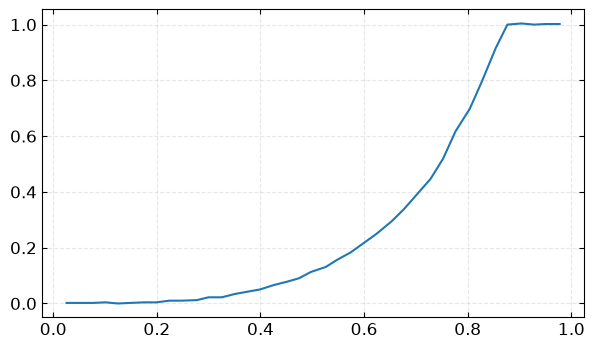

In [242]:
plt.plot(x_mpp, y_mpp)

In [243]:

#plt.plot([(dist_flat_mm>0.2) & (dist_flat_mm<1)][400:800], cce_flat[(dist_flat_mm>0.2) & (dist_flat_mm<1)][400:800])
#plt.scatter([0.4], [CCE_func(0.4)], color = 'red')
#plt.plot(x_mpp, y_mpp, color = 'orange')


In [244]:
cce_interp_cubi_mpp = interp1d(
    x_mpp,              # mm
    y_mpp,                # CCE
    kind="cubic",
    bounds_error=False,
    fill_value=(cce[0], 1),
)
def CCE_func_mpp(d_mm):
    return np.clip(cce_interp_cubi_mpp(d_mm), 0.0, 1.0)

In [245]:
# Ricostruisci la struttura originale
charge_collection_eff_mpp = ak.unflatten(
    CCE_func_mpp(dist_flat_mm),
    ak.num(data.dist_to_surf)
)

In [246]:
energy_mpp = ak.sum(data.edep * charge_collection_eff_mpp, axis=-1)

In [247]:
0.6*2.355

1.413

In [248]:
energy_smeared_mpp = reboost.math.stats.gaussian_sample(
        energy_mpp,
        sigma=0.6,)


fig, ax = plt.subplots(dpi = 300)

def plot_edep(detid):
    data = lh5.read_as(f"stp/{detid}", "out.lh5", "ak")

    (
        hist.new
        .Reg(500, 10, 500, name="Energy [keV]")
        .Double()
        .fill(ak.sum(data.edep, axis=-1))
        .plot(
            ax=ax,
            yerr=False,
            histtype="step",
            color="#1A2A5B",
            #edgecolor="#1A2A5B",
            linewidth=1.2,
            label=detid,
        )
    )

plot_edep("Bob")
ax.hist(energy_smeared, bins = 100, range = (20, 90))
ax.set_xlim(20,90)
ax.set_ylim(1e3,1e6)
ax.set_yscale('log')

(20.0, 90.0)

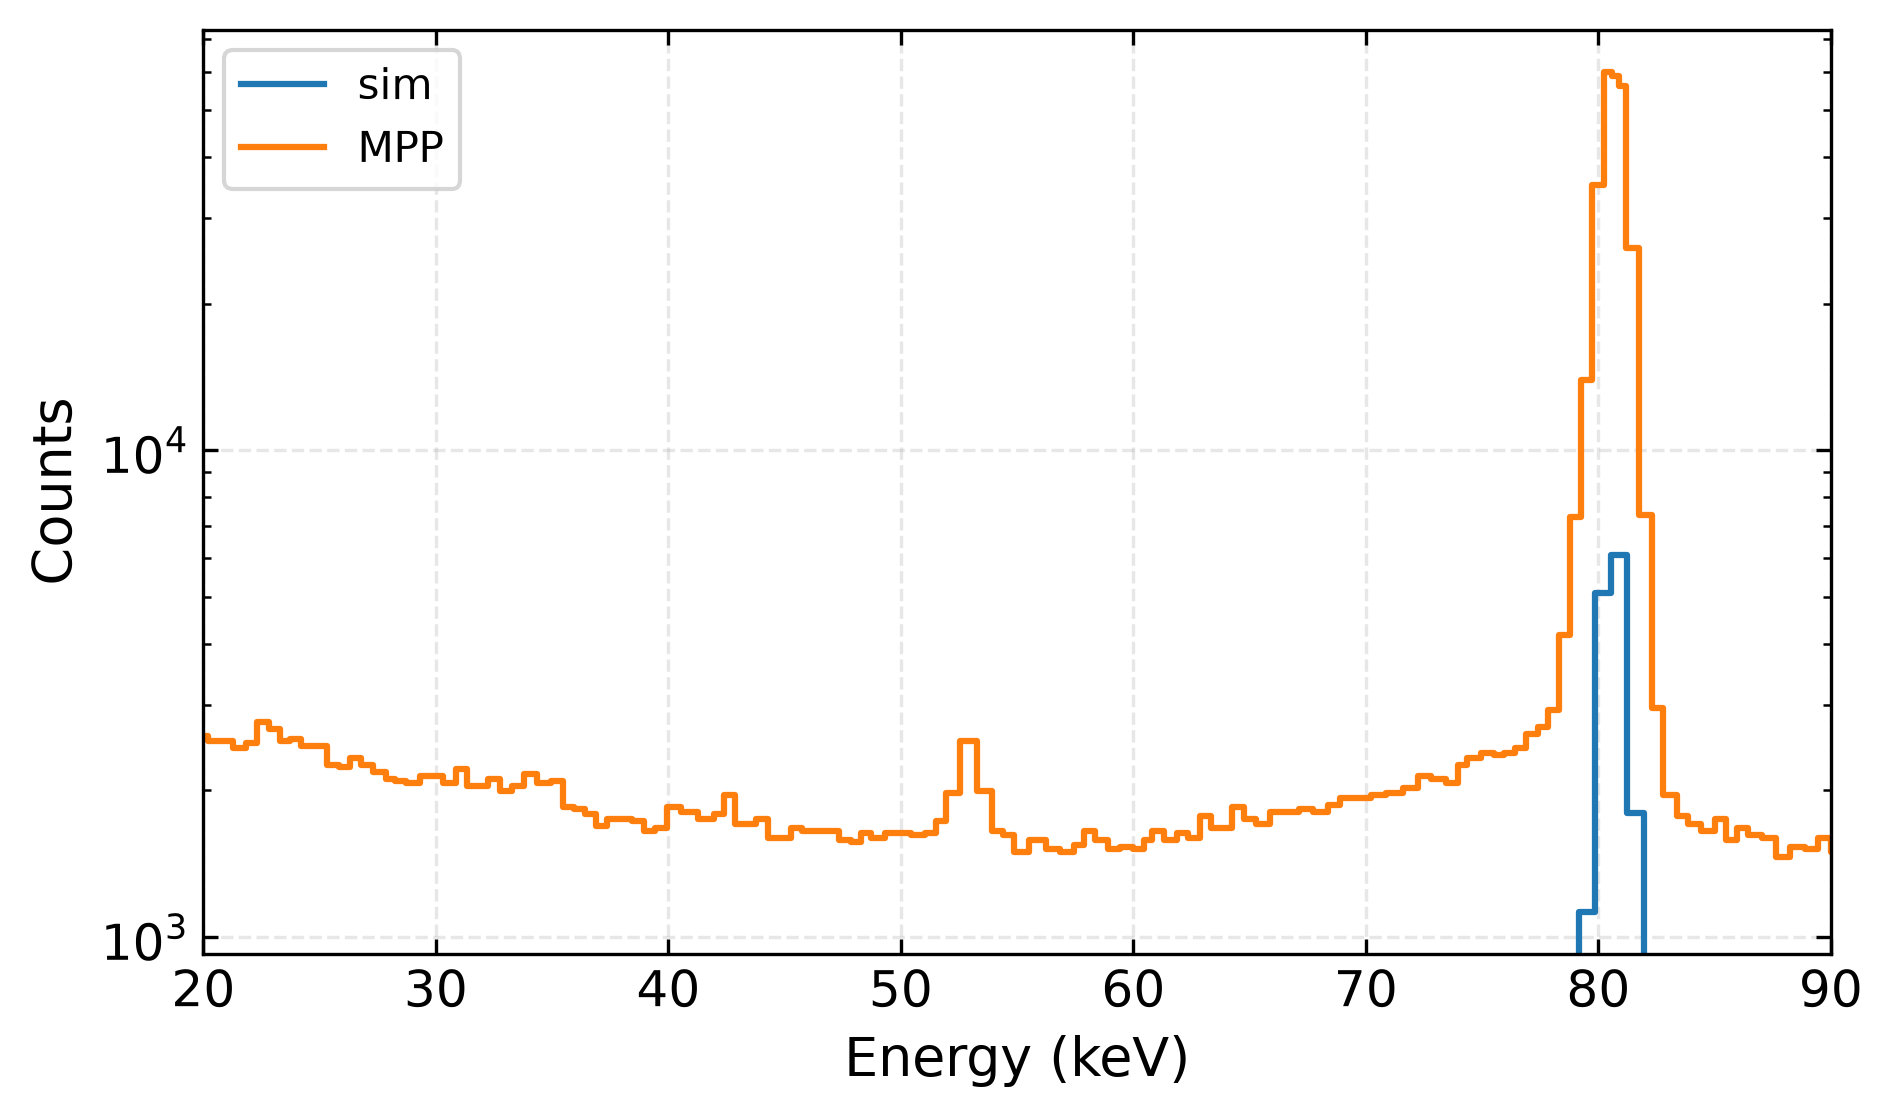

In [249]:
plt.figure(dpi = 300)
countsmpp, edgesmpp = np.histogram(
    energy_smeared_mpp,
    bins=100,
    range=(20,90)
)

shift = 1000  # quantità di spostamento verticale

plt.step(
    edgesmpp[:-1],
    countsmpp - shift,
    where="mid",
    label = 'sim'
)

plt.step(E_exp, N_exp, where="mid",
    label = 'MPP')
plt.legend()
plt.yscale('log')
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.xlim(20,90)


## energy deposition


In [250]:
reg = pyg4ometry.gdml.Reader("geometry.gdml").getRegistry()
hpge_pyobj = hpges.make_hpge(bege_meta, registry=None)
position = reg.physicalVolumeDict["Bob"].position.eval()

In [251]:
print(reg.physicalVolumeDict.keys())

dict_keys(['Source', 'Bob', 'Polyethylene', 'Vacuum'])


In [252]:
stp = lh5.read_as("stp/Bob", "out.lh5", "ak", with_units=True)

In [253]:
dist_all = reboost.hpge.surface.distance_to_surface(
    stp.xloc, stp.yloc, stp.zloc, hpge_pyobj, position
)

dist_nplus = reboost.hpge.surface.distance_to_surface(
    stp.xloc,
    stp.yloc,
    stp.zloc,
    hpge_pyobj,
    position,
    surface_type="nplus",
)

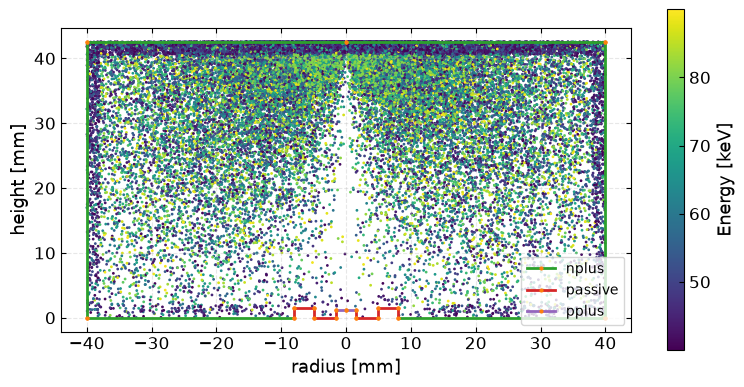

In [254]:
# numero massimo di punti da visualizzare
nmax = 50000
rng = np.random.default_rng()

# Flatten una sola volta
x = ak.to_numpy(ak.flatten(stp.xloc)) * 1000
y = ak.to_numpy(ak.flatten(stp.yloc)) * 1000
z = ak.to_numpy(ak.flatten(stp.zloc)) * 1000 - position[2]
edep = ak.to_numpy(ak.flatten(stp.edep))
dist = ak.to_numpy(ak.flatten(dist_nplus))

# Coordinate cilindriche
r = np.hypot(x - position[0], y - position[1])

# Rendi il raggio positivo o negativo casualmente
r *= rng.choice([-1, 1], size=r.size)

# Applica il taglio una sola volta
mask = (edep > 40) & (edep < 90)

r_plot = r[mask]
z_plot = z[mask]
e_plot = edep[mask]

# Sottocampionamento casuale
if r_plot.size > nmax:
    idx = rng.choice(r_plot.size, size=nmax, replace=False)
    r_plot = r_plot[idx]
    z_plot = z_plot[idx]
    e_plot = e_plot[idx]

# Plot
fig, ax = plt.subplots(figsize=(8, 4))#, dpi=300)

pygeomhpges.draw.plot_profile(
    hpge_pyobj,
    axes=ax,
    split_by_type=True
)

sc = ax.scatter(
    r_plot,
    z_plot,
    c=e_plot,
    s=4,
    marker=".",
    cmap="viridis",
     vmin=min(e_plot),
    vmax=max(e_plot),
    rasterized=True,   # utile se salvi in PDF/SVG
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Energy [keV]")

ax.set_aspect("equal")
ax.set_xlabel("radius [mm]")
ax.set_ylabel("height [mm]")
ax.legend(loc = 'lower right')
plt.tight_layout()
plt.show()

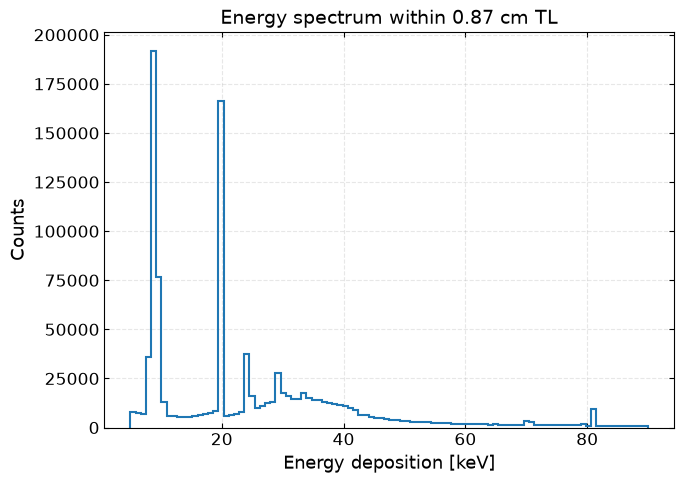

In [282]:
# TL thickness
tl_thickness = 8.7  # mm

mask_tl = (
    (edep > 5) &
    (edep < 90) &
    (dist <= tl_thickness)
)

e_tl = edep[mask_tl]

fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(
    e_tl,
    bins=100,
    histtype="step",
    linewidth=1.5
)

ax.set_xlabel("Energy deposition [keV]")
ax.set_ylabel("Counts")
ax.set_title("Energy spectrum within 0.87 cm TL")

ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# CONFRONTO PIU CURVE

In [255]:
from tqdm import tqdm

In [256]:
countsmpp, edgesmpp = np.histogram(
    energy_smeared_mpp,
    bins=100,
    range=(20,90)
)

--------------------------------
CCE simulation
--------------------------------
seed = 1
--------------------------------

Generating Li distribution...
alpha 2.50e-10
Saturation depth = 0.66 mm


Li slices: 100%|██████████| 66/66 [00:03<00:00, 16.78it/s]


Total Li particles = 16620
alpha = 2.5e-10
seed = 3398028610
Numero Li: 16620
Profondità saturazione: 0.66 mm

Starting CCE simulation...



CCE depth:   0%|          | 0/20 [00:00<?, ?it/s]

Charge initial position: 0.0


...

Charge initial position: 0.08


CCE depth:  85%|████████▌ | 17/20 [01:31<00:45, 15.27s/it]

Charge initial position: 0.085


CCE depth: 100%|██████████| 20/20 [01:33<00:00,  4.65s/it]


Charge initial position: 0.09
Charge initial position: 0.095


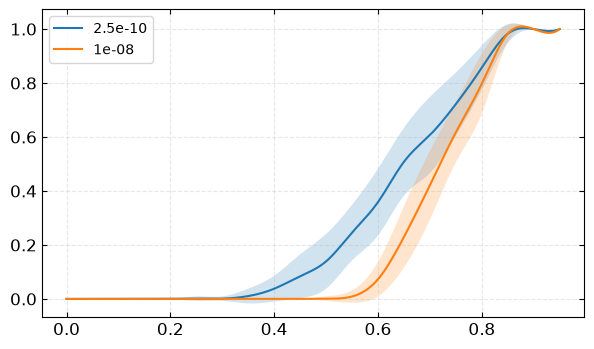

In [283]:
alphas = [ 2.5e-10, 7.5e-10, 1e-9, 5e-9, 1e-8]

alphas = [ 2.5e-10, 1e-8]

histograms = {}

CCE_dict = {}


for alpha in alphas:
    importlib.reload(simulate_CCE)

    # LITHIUM GENERATION
    seed = np.random.SeedSequence().generate_state(1)[0]
    my_args = argparse.Namespace(        
            seed=int(seed),        
            N_charges=15,        
            N_repeat=125,        
            alpha=alpha,     
            FCCD = 0.085,         
            T_ann=623,        
            t_ann=18*60,        
            output="library"
        )
        
    params = simulate_CCE.update_parameters(my_args)
    cells, saturation_depth, px, py, pz = simulate_CCE.generate_lithium(params)
    print("alpha =", alpha)
    print("seed =", my_args.seed)
    print("Numero Li:", len(px))
    print("Profondità saturazione:", saturation_depth*10, "mm")

    # CHARGES EVOLUTION
    x, CCE_matrix, CCE_mean, CCE_std = simulate_CCE.simulate_CCE(
        cells,
        saturation_depth,
        px,
        py,
        pz,
        my_args
    )

    CCE_min = np.min(CCE_matrix, axis=1)
    CCE_max = np.max(CCE_matrix, axis=1)
    cce_min = np.array(CCE_min)
    cce_max = np.array(CCE_max)

    # INTERPOLATION
    depth = np.array(x) * 10   # da cm a mm
    cce = CCE_mean
    cce_std = CCE_std
    cce_interp = interp1d(
        depth,
        cce,
        kind='cubic',          
        bounds_error=False,
        fill_value=(cce[0], 1.0)   # fuori dall'intervallo
    )
    cce_min_interp = interp1d(
        depth,
        cce_min,
        kind='cubic',
        bounds_error=False,
        fill_value=(cce_min[0], 1.0)
    )
    cce_max_interp = interp1d(
        depth,
        cce_max,
        kind='cubic',
        bounds_error=False,
        fill_value=(cce_max[0], 1.0)
    )
    cce_std_interp = interp1d(
        depth,
        cce_std,
        kind='cubic',
        bounds_error=False,
        fill_value=(cce_std[0], cce_std[-1])
    )
        
    # Griglia fitta
    depth_fine = np.linspace(depth.min(), depth.max(), 500)
    # Valori interpolati
    cce_fine = cce_interp(depth_fine)
    cce_min_fine = cce_min_interp(depth_fine)
    cce_max_fine = cce_max_interp(depth_fine)
    cce_std_fine = cce_std_interp(depth_fine)


    def CCE_func(d_mm):
        mean = cce_interp(d_mm)
        std = cce_std_interp(d_mm)
    
        # Random uniforme tra -1 e +1
        random_factor = np.random.uniform(
            -1.0,
            1.0,
            size=np.asarray(d_mm).shape
        )
    
        cce_random = mean + random_factor * std
    
        return np.clip(
            cce_random,
            0.0,
            1.0
        )



    plt.errorbar(
        depth_fine,
        cce_fine,
        #yerr=CCE_std,
        label = f'{alpha}'
    )
    plt.fill_between(
        depth_fine,
        cce_fine-cce_std_fine,
        cce_fine+cce_std_fine,
        alpha=0.2
    )
    plt.legend()


    # ENERGY CORRECTION
    dist_flat_mm = ak.to_numpy(ak.flatten(data.dist_to_surf)) * 1000.0
    charge_collection_eff = ak.unflatten(
        CCE_func(dist_flat_mm),
        ak.num(data.dist_to_surf)
    )

    energy = ak.sum(data.edep * charge_collection_eff, axis=-1)
    energy_smeared = reboost.math.stats.gaussian_sample(
        energy,
        sigma=0.6,)

    counts, edges = np.histogram(
        energy_smeared,
        bins=100,
        range=(20,90)
        #range=(35,90)
    )

    histograms[alpha] = (counts, edges)
    CCE_dict[alpha] = (depth_fine, cce_fine)


    

In [268]:
histograms.keys()

dict_keys([2.5e-10, 7.5e-10, 1e-09, 5e-09, 1e-08])

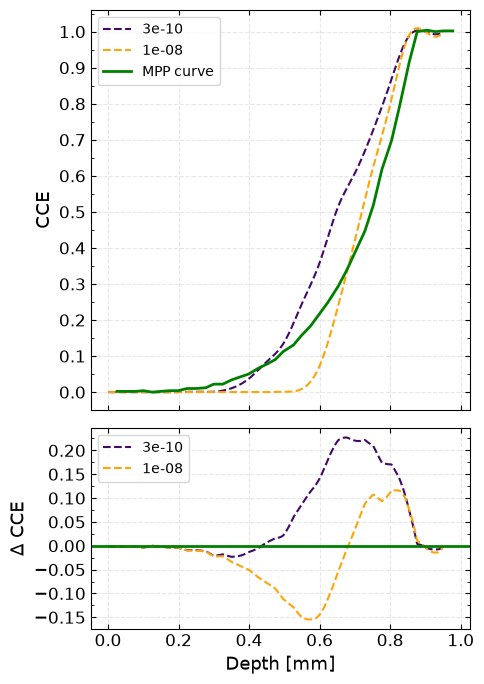

In [285]:
from matplotlib.ticker import MultipleLocator

colors = plt.colormaps["inferno"](
    np.linspace(0.2, 0.8, len(alphas))
)

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(5, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

# --- Plot principale ---
for i, alpha in enumerate(alphas):
    x, CCE_mean = CCE_dict[alpha]

    ax1.plot(
        x, CCE_mean,
        color=colors[i],
        ls='--',
        label=f"{alpha:.0e}"
    )

ax1.plot(
    x_mpp, y_mpp,
    color='green',
    lw=2,
    label="MPP curve"
)

ax1.set_ylabel("CCE")
ax1.legend()

# Più tacche sull'asse Y
ax1.yaxis.set_major_locator(MultipleLocator(0.1))
ax1.yaxis.set_minor_locator(MultipleLocator(0.05))


# --- Differenza verticale rispetto alla curva MPP ---
for i, alpha in enumerate(alphas):
    x, CCE_mean = CCE_dict[alpha]

    y_mpp_interp = np.interp(x, x_mpp, y_mpp)

    delta = CCE_mean - y_mpp_interp

    ax2.plot(
        x, delta,
        color=colors[i],
        ls='--',
        label=f"{alpha:.0e}"
    )

ax2.axhline(
    0,
    color='green',
    lw=2
)

ax2.set_xlabel("Depth [mm]")
ax2.set_ylabel(r"$\Delta$ CCE")
ax2.legend()

# Più tacche sull'asse Y del secondo plot
ax2.yaxis.set_major_locator(MultipleLocator(0.05))
ax2.yaxis.set_minor_locator(MultipleLocator(0.025))

plt.tight_layout()
plt.show()

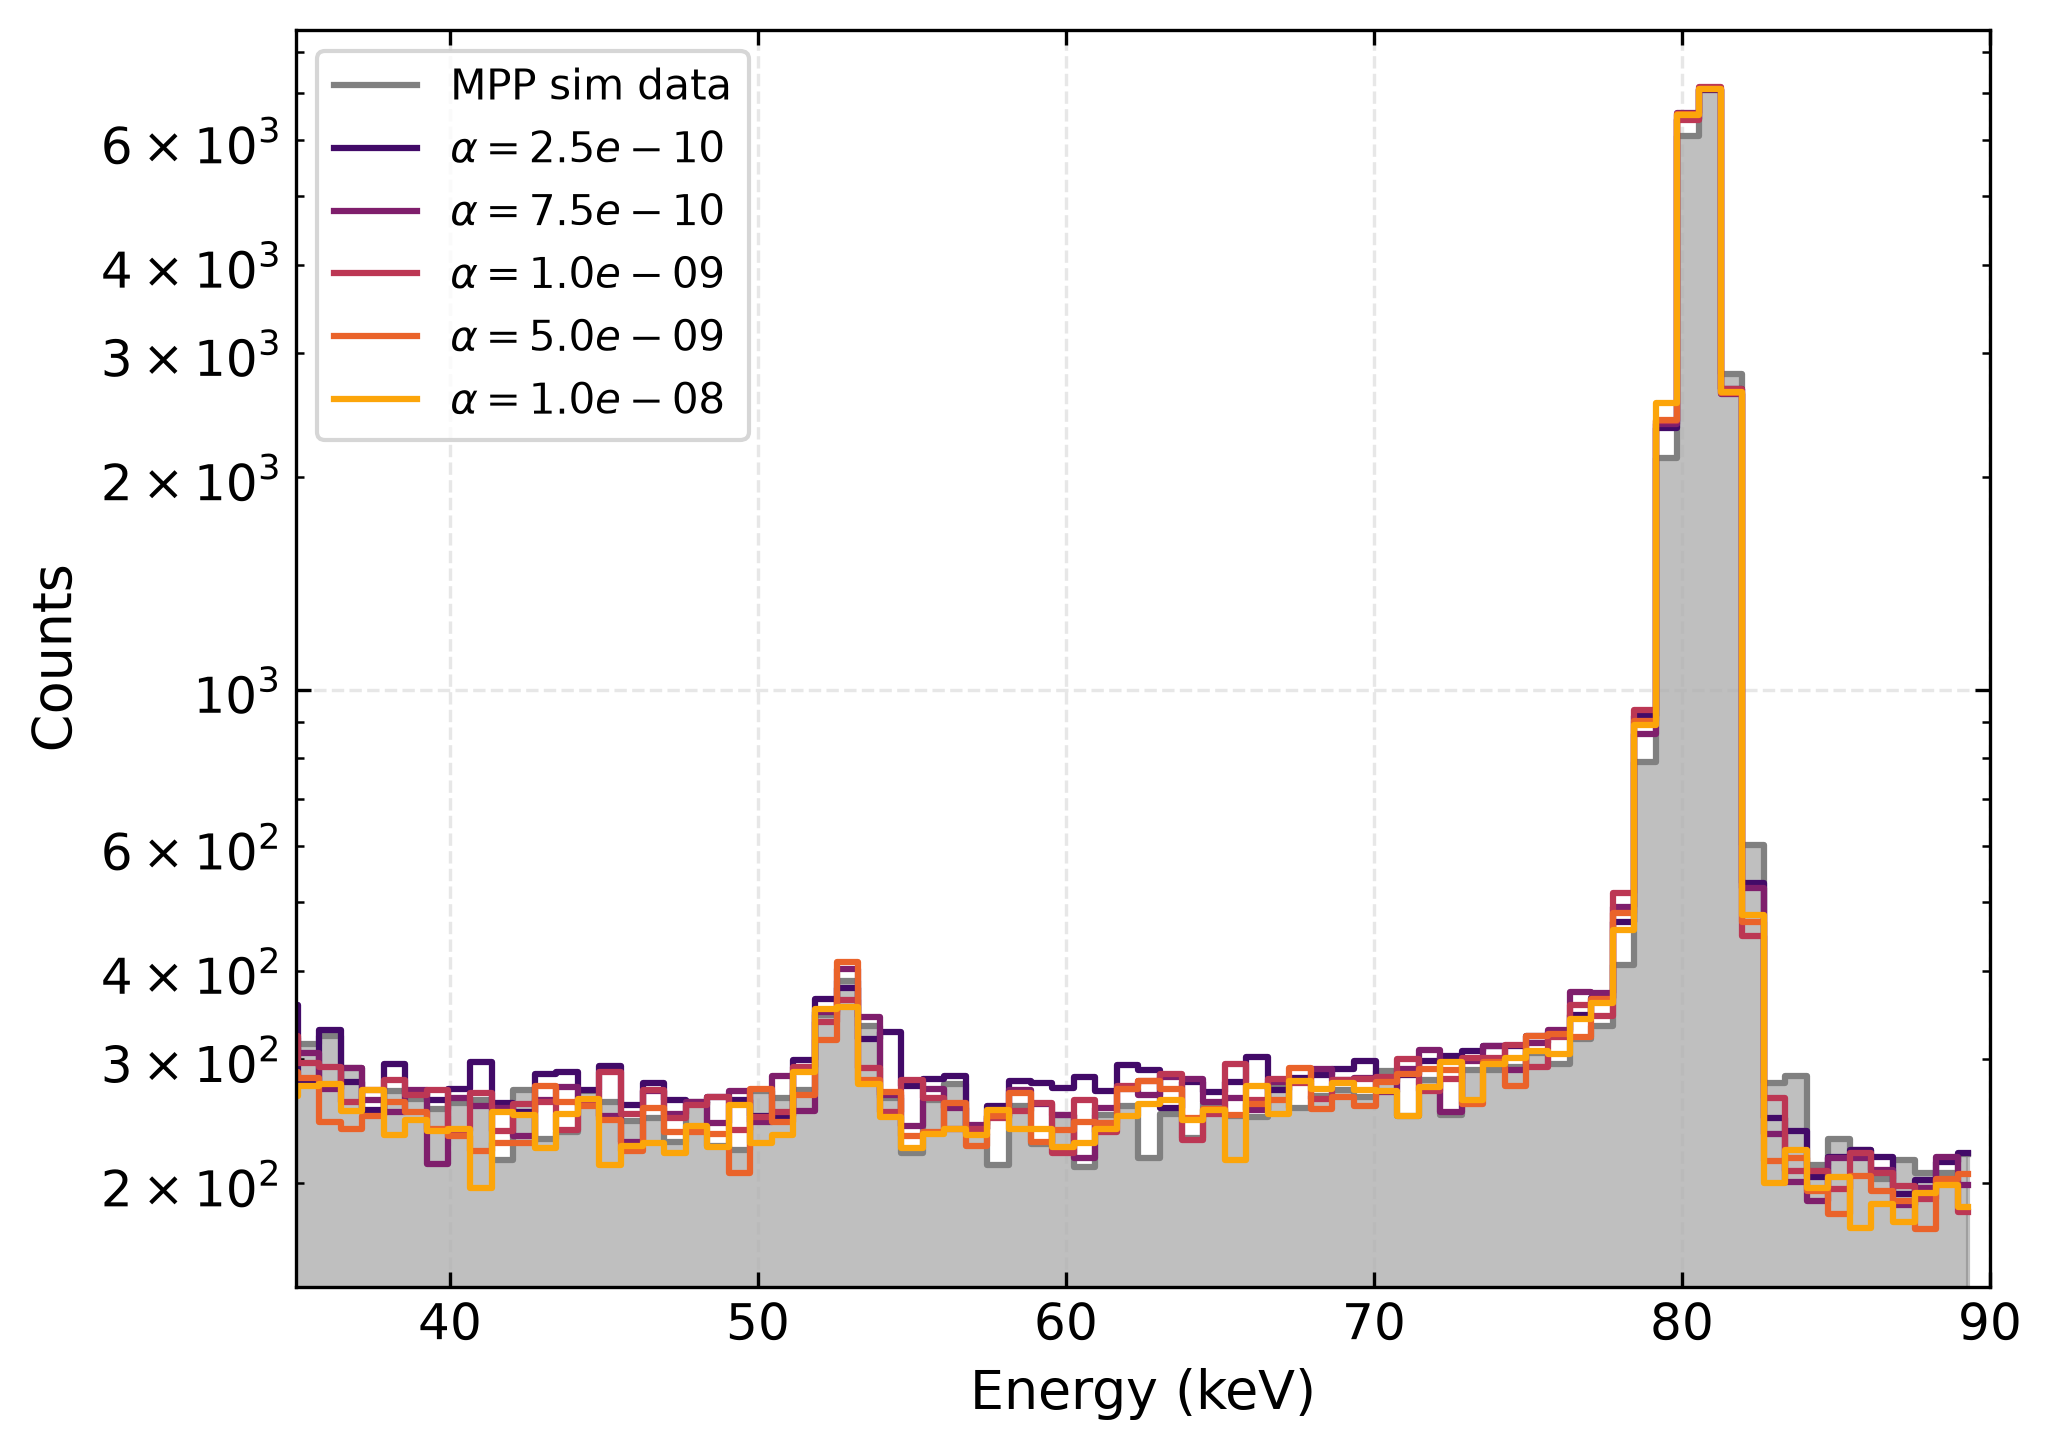

In [275]:
shift = 0
plt.figure(figsize=(7, 5), dpi=300)
# dati MPP
plt.step(
    edgesmpp[:-1],
    countsmpp - shift,
    where="mid",
    color="gray",
    linewidth=1.5,
    label="MPP sim data"
)
plt.fill_between(
    edgesmpp[:-1],
    countsmpp - shift,
    step="mid",
    color="gray",
    alpha=0.5
)

colors = plt.colormaps["inferno"](
    np.linspace(0.2, 0.8, len(alphas))
)


for i, (alpha, (counts, edges)) in enumerate(histograms.items()):

    plt.step(
        edges[:-1],
        counts - shift,                 
        where="mid",
        color = colors[i],
        label=fr'$\alpha={alpha:.1e}$'
    )





plt.yscale("log")
plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.xlim(35, 90)

plt.legend()
plt.tight_layout()
plt.show()

In [277]:
# ============================================================
# 2. Calcolo del chi quadro tra 35 e 90 keV
# ============================================================

chi2_results = {}

for alpha, (counts, edges) in histograms.items():

    counts = np.asarray(counts, dtype=float)
    expected = np.asarray(countsmpp, dtype=float)
    edges = np.asarray(edges, dtype=float)
    edges_mpp = np.asarray(edgesmpp, dtype=float)

    # --------------------------------------------------------
    # Controllo che i bin siano uguali
    # --------------------------------------------------------
    if len(edges) != len(edges_mpp):
        raise ValueError(
            f"Numero di bin diverso per alpha={alpha:.1e}"
        )

    if not np.allclose(edges, edges_mpp):
        raise ValueError(
            f"I bin non coincidono per alpha={alpha:.1e}"
        )

    # --------------------------------------------------------
    # Considera SOLO l'intervallo 35-90 keV
    # --------------------------------------------------------
    bin_centers = 0.5 * (edges[:-1] + edges[1:])

    # --------------------------------------------------------
    # Considera SOLO 35 <= Energy <= 90 keV
    # --------------------------------------------------------
    # energy_mask = ( (bin_centers >= 35) &  (bin_centers <= 90))
    #energy_mask = (edges >= edges.min()) & (edges <= edges.max())

    #counts_sel = counts[energy_mask]
    #expected_sel = expected[energy_mask]
    counts_sel = counts
    expected_sel = expected

    # --------------------------------------------------------
    # Elimina i bin dove MPP = 0
    # --------------------------------------------------------
    mask = expected_sel > 0

    observed = counts_sel[mask]
    expected_valid = expected_sel[mask]

    # --------------------------------------------------------
    # Chi quadro
    # --------------------------------------------------------
    chi2 = np.sum(
        (observed - expected_valid)**2
        / expected_valid
    )

    # --------------------------------------------------------
    # Gradi di libertà
    # --------------------------------------------------------
    dof = len(observed) - 1

    # --------------------------------------------------------
    # Chi quadro ridotto
    # --------------------------------------------------------
    chi2_red = chi2 / dof

    # --------------------------------------------------------
    # Salva risultati
    # --------------------------------------------------------
    chi2_results[alpha] = {
        "chi2": chi2,
        "dof": dof,
        "chi2_red": chi2_red
    }


# ============================================================
# Stampa risultati
# ============================================================

for alpha in sorted(chi2_results):

    result = chi2_results[alpha]

    print(
        f"alpha = {alpha:.1e} | "
        f"chi2 = {result['chi2']:.2f} | "
        f"dof = {result['dof']} | "
        f"chi2_red = {result['chi2_red']:.4f}"
    )


# ============================================================
# Miglior alpha
# ============================================================

best_alpha = min(
    chi2_results,
    key=lambda a: chi2_results[a]["chi2_red"]
)

print("\nBest alpha:")
print(f"alpha = {best_alpha:.1e}")
print(f"chi2_red = {chi2_results[best_alpha]['chi2_red']:.4f}")

alpha = 2.5e-10 | chi2 = 411.86 | dof = 99 | chi2_red = 4.1602
alpha = 7.5e-10 | chi2 = 403.92 | dof = 99 | chi2_red = 4.0800
alpha = 1.0e-09 | chi2 = 500.65 | dof = 99 | chi2_red = 5.0571
alpha = 5.0e-09 | chi2 = 668.55 | dof = 99 | chi2_red = 6.7530
alpha = 1.0e-08 | chi2 = 835.82 | dof = 99 | chi2_red = 8.4426

Best alpha:
alpha = 7.5e-10
chi2_red = 4.0800


In [278]:
# ============================================================
# 3. Stampa dei risultati
# ============================================================

print("\n" + "="*65)
print("CHI-QUADRO CONFRONTO CON SPETTRO MPP")
print("="*65)

for alpha in sorted(chi2_results):

    chi2 = chi2_results[alpha]["chi2"]
    dof = chi2_results[alpha]["dof"]
    chi2_red = chi2_results[alpha]["chi2_red"]

    print(
        f"alpha = {alpha:.1e}   "
        f"chi2 = {chi2:.2f}   "
        f"dof = {dof:d}   "
        f"chi2_red = {chi2_red:.4f}"
    )



CHI-QUADRO CONFRONTO CON SPETTRO MPP
alpha = 2.5e-10   chi2 = 411.86   dof = 99   chi2_red = 4.1602
alpha = 7.5e-10   chi2 = 403.92   dof = 99   chi2_red = 4.0800
alpha = 1.0e-09   chi2 = 500.65   dof = 99   chi2_red = 5.0571
alpha = 5.0e-09   chi2 = 668.55   dof = 99   chi2_red = 6.7530
alpha = 1.0e-08   chi2 = 835.82   dof = 99   chi2_red = 8.4426


In [279]:
best_alpha = min(
    chi2_results,
    key=lambda alpha: chi2_results[alpha]["chi2_red"]
)

best_chi2 = chi2_results[best_alpha]["chi2"]
best_dof = chi2_results[best_alpha]["dof"]
best_chi2_red = chi2_results[best_alpha]["chi2_red"]

print("\n" + "="*65)
print("MIGLIOR FIT")
print("="*65)

print(f"Best alpha       = {best_alpha:.4e}")
print(f"chi2             = {best_chi2:.4f}")
print(f"degrees of freedom = {best_dof}")
print(f"reduced chi2     = {best_chi2_red:.4f}")



MIGLIOR FIT
Best alpha       = 7.5000e-10
chi2             = 403.9210
degrees of freedom = 99
reduced chi2     = 4.0800


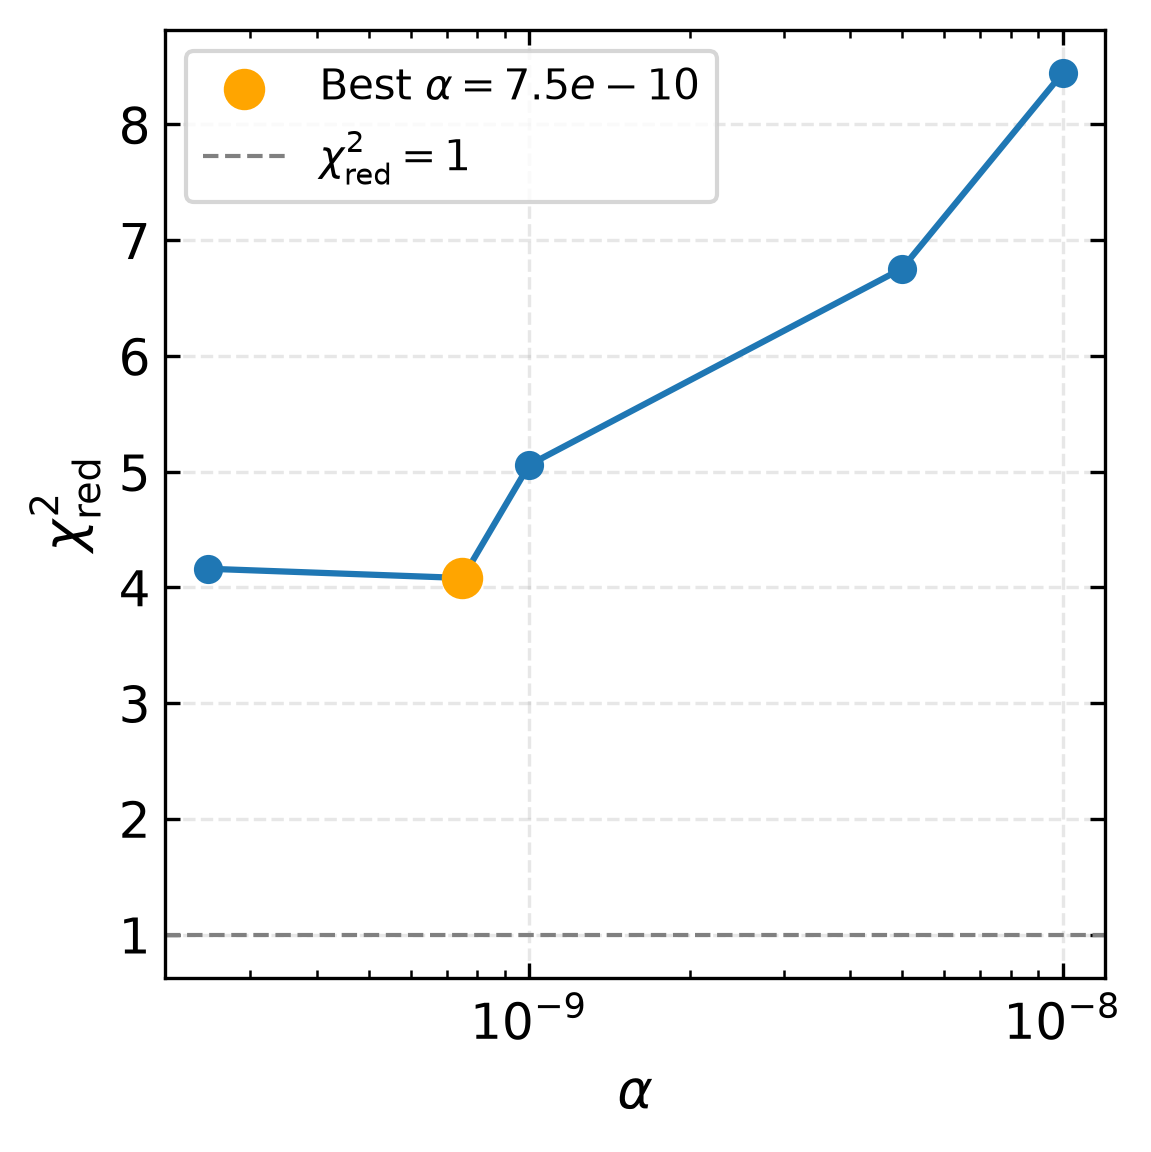

In [280]:

# ============================================================
# 5. Plot del chi quadro ridotto vs alpha
# ============================================================

alpha_values = np.array(sorted(chi2_results))

chi2_red_values = np.array([
    chi2_results[alpha]["chi2_red"]
    for alpha in alpha_values
])

chi2_red_values = chi2_red_values

plt.figure(figsize=(4, 4), dpi=300)

plt.plot(
    alpha_values,
    chi2_red_values,
    'o-',
    linewidth=1.5,
    markersize=6
)

# Evidenzia il miglior alpha
plt.scatter(
    best_alpha,
    best_chi2_red,
    s=80,
    color = 'orange',
    zorder=5,
    label=fr'Best $\alpha={best_alpha:.1e}$'
)

# Riferimento chi2 ridotto = 1
plt.axhline(
    1,
    color="gray",
    linestyle="--",
    linewidth=1,
    label=r"$\chi^2_\mathrm{red}=1$"
)

plt.xscale("log")

plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\chi^2_\mathrm{red}$")

plt.legend()
plt.tight_layout()
plt.show()